In [1]:
import sys
sys.path.append("../")  # Goes up to "project/"
import parameters as var
import model_gan as mg
import torch
import torch.nn as nn
import torch.optim as optim
import data_loader as dl
import train_gan as tg
import time

import numpy as np
import matplotlib.pyplot as plt
var.init()
var.print_parameters()

*********** Configuration parameters ***********
* β=2, Nx=32, Nt=32
* Variables=2048
* m0=-0.1884
* blocks_x=2, blocks_t=2 (for the aggregation)
* SAP vectors for the loss function Nv=30
* Fake test vectors generated Nv=10
* Number of confs=500
* Confs used for training=50
* Device: cuda:0
* Precision: double
* DOF on fine grid: 2048
* DOF on coarse grid: 80
* Gauge equivariant model: True
************************************************


Some tests

In [2]:
#import tests as tests
#batch_size = 10
#T = tests.Test(batch_size)
#T.check_u1_vars()
#T.test_G_and_D()

# Loading data

In [3]:
confID = 0
num_examples = 500
dataset = dl.ConfsDataset(confID,num_examples) 
train_len = len(dataset)      
torch.manual_seed(42)      
print("Training examples",train_len)

workers    = 2
batch_size = 10

#train dataloader
train_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,          # we usually want shuffling *only* for training
    num_workers=workers,
    pin_memory=True
)

#----returns a tensor of size [ [batch_size,2,Nt,Nx], [batch_size,2,Nt,Nx], [batch_size]]----#
#    = U (complex), Tv (complex), Idx (integers)
first_batch = next(iter(train_loader)) 
#--------------------------------------
print(first_batch[0].shape,first_batch[0].dtype)
print(first_batch[1].shape,first_batch[1].dtype)
print(first_batch[2].shape,first_batch[2].dtype)

Training examples 500
torch.Size([10, 2, 32, 32]) torch.complex128
torch.Size([10, 2, 32, 32]) torch.complex128
torch.Size([10]) torch.int64


# Declaring models

In [4]:
D = mg.Discriminator(var.NGPU,batch_size).to(var.DEVICE)
G = mg.Generator(var.NGPU,batch_size).to(var.DEVICE)
print(G)
print(D)
params = sum(p.numel() for p in D.parameters() if p.requires_grad)
params += sum(p.numel() for p in G.parameters() if p.requires_grad)
data_points = 2*var.NX*var.NT*train_len
print("Total (complex) parameters",params)
print("Total (complex) data points",data_points)
print("parameters/data_points",params/data_points)

Generator(
  (lcnn_layers): MultiInputSequential(
    (0): LPTConv()
    (1): LPTConv()
  )
)
Discriminator(
  (sigmoid): Sigmoid()
  (lcnn_layers): MultiInputSequential(
    (0): LConv()
    (1): LConv()
    (2): LConv()
    (3): LConv()
    (4): LConv()
    (5): LConv()
  )
)
Total (complex) parameters 11094
Total (complex) data points 1024000
parameters/data_points 0.010833984375


In [5]:
# Learning rate for optimizers
lr = 0.01
# Beta1 hyperparameter for Adam optimizers
beta1 = 0.9
beta2 = 0.999
lamb = 0
optimizerD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2),weight_decay=lamb)
optimizerG = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2),weight_decay=lamb)

In [6]:
#Loss function for D
criterion = nn.BCELoss()

# Training loop

In [7]:
lossesG = []
lossesD = []

start = time.time()

epochs = 20
losses = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    tg.train(train_loader, G, D, criterion, optimizerG,optimizerD,lossesG,lossesD)
print("Done!")

end = time.time()
print(end - start,"s")

#with open("losses.txt", "w") as outfile:
#    outfile.write("\n".join(str(item) for item in losses))

Epoch 1
-------------------------------
[0/50]	Loss_D: 99.9707	Loss_G: 49.8193	D(x): 0.5021	D(G(z)): 0.5018 / 0.5018
[10/50]	Loss_D: 99.4985	Loss_G: 50.2734	D(x): 0.5015	D(G(z)): 0.4965 / 0.4973
[20/50]	Loss_D: 100.3955	Loss_G: 50.0342	D(x): 0.4957	D(G(z)): 0.4996 / 0.4997
[30/50]	Loss_D: 99.9004	Loss_G: 49.9658	D(x): 0.5000	D(G(z)): 0.4991 / 0.5003
[40/50]	Loss_D: 100.2539	Loss_G: 49.8438	D(x): 0.4983	D(G(z)): 0.5008 / 0.5016
Epoch 2
-------------------------------
[0/50]	Loss_D: 99.8682	Loss_G: 50.2930	D(x): 0.4992	D(G(z)): 0.4979 / 0.4971
[10/50]	Loss_D: 99.8486	Loss_G: 50.2393	D(x): 0.4992	D(G(z)): 0.4977 / 0.4976
[20/50]	Loss_D: 100.3320	Loss_G: 49.8730	D(x): 0.4983	D(G(z)): 0.5016 / 0.5013
[30/50]	Loss_D: 98.9111	Loss_G: 50.2979	D(x): 0.5085	D(G(z)): 0.4976 / 0.4970
[40/50]	Loss_D: 99.9561	Loss_G: 49.7998	D(x): 0.5023	D(G(z)): 0.5019 / 0.5020
Epoch 3
-------------------------------
[0/50]	Loss_D: 100.1221	Loss_G: 49.7119	D(x): 0.5016	D(G(z)): 0.5028 / 0.5029
[10/50]	Loss_D: 99.10

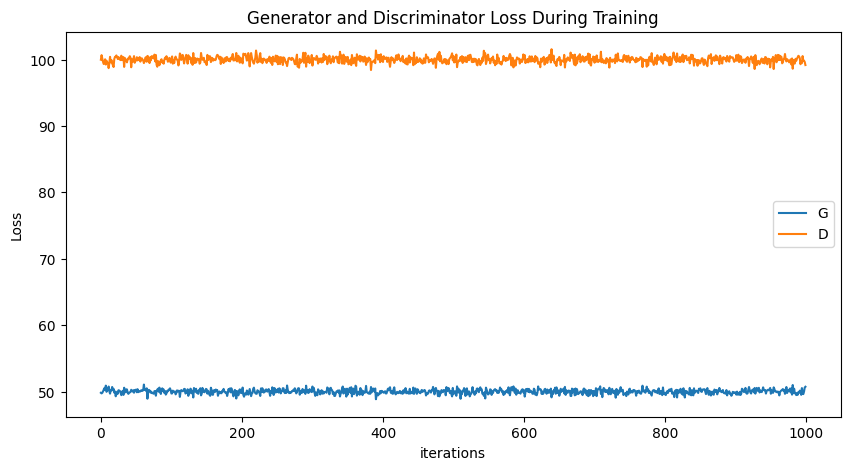

In [8]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(lossesG,label="G")
plt.plot(lossesD,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Generating test vectors

In [9]:
with torch.no_grad():
    batch = next(iter(train_loader)) 
    
    #Random noise for the generator
    std = 0.5 
    real = torch.empty(batch_size, 1, var.NT, var.NX, dtype=var.PREC, device=var.DEVICE) #(B,1,NT,NX)
    imag = torch.empty(batch_size, 1, var.NT, var.NX, dtype=var.PREC, device=var.DEVICE)
    nn.init.normal_(real, mean=0.0, std=std)
    nn.init.normal_(imag, mean=0.0, std=std)
    random_noise = torch.complex(real, imag)
    batch = next(iter(train_loader)) 
    
    u = batch[0].to(var.DEVICE)
    fake_tv = G(u,random_noise) #(B,2,Nt,Nx)
    print("Predictions shape",fake_tv.shape)
    
    norms = torch.linalg.vector_norm(fake_tv[:],dim=(-3,-2, -1)).view(batch_size, 1, 1, 1)
    pred_complex_normalized = fake_tv / norms
    pred_complex_normalized = pred_complex_normalized.cpu().detach().numpy()

Predictions shape torch.Size([10, 2, 32, 32])


Norm 8.979252529651314 1.0


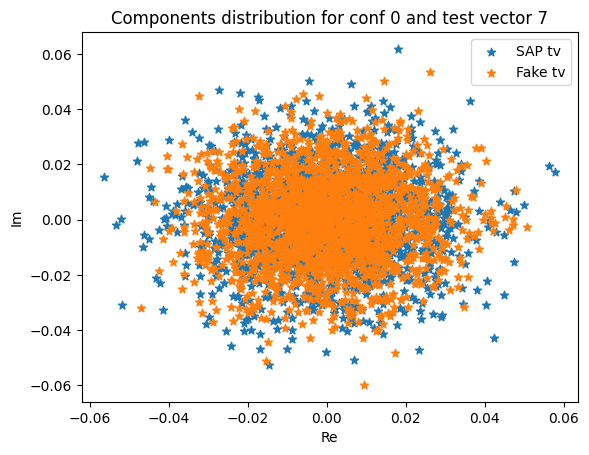

In [13]:
tv = 7
norm = np.linalg.norm(batch[1][tv].reshape(2*var.NX*var.NT))
norm_pred = np.linalg.norm(pred_complex_normalized[tv].reshape(2*var.NX*var.NT))
print("Norm",norm,norm_pred)

fig = plt.figure(dpi=100)
plt.title("Components distribution for conf {0} and test vector {1}".format(confID,tv))

plt.scatter(np.real(batch[1][tv].reshape(2*var.NX*var.NT))/norm,
            np.imag(batch[1][tv].reshape(2*var.NX*var.NT))/norm,
            marker="*",label="SAP tv")

plt.scatter(np.real(pred_complex_normalized[tv].reshape(2*var.NX*var.NT))/norm_pred,
            np.imag(pred_complex_normalized[tv].reshape(2*var.NX*var.NT))/norm_pred,
            marker="*",
            label="Fake tv")

plt.xlabel("Re")
plt.ylabel("Im")
plt.legend()
plt.show()